In [2]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import scipy
import cartopy.crs as ccrs
import geopandas as gpd
import rioxarray
import cartopy.feature as cf
from rasterio.enums import Resampling


In [7]:
# load observed seasonal streamflow data
obs_df = pd.read_csv('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/obs/streamflow/streamflow_obs_autumn_converted.csv')
obs_df.date = pd.to_datetime(obs_df.date)
obs_df.set_index('date', inplace=True)
obs_df = obs_df['1969':'2019'] 

# load streamflow metadata
metadata_df = pd.read_csv('/nesi/project/niwa00015/queenle/data/metadata/40_50yr_sites.csv')
metadata_df.set_index('Number',inplace=True)
subset_meta = metadata_df.loc[[int(s) for s in seasonal_flow_df.columns]]
subset_meta.sort_values('gauge_lat', ascending = False, inplace=True)
subset_meta['number_label'] = np.arange(1,len(subset_meta)+1)
subset_meta['number_copy'] = subset_meta.index.values.tolist()
meta_df = gpd.GeoDataFrame(subset_meta,geometry=gpd.points_from_xy(x=subset_meta.gauge_lon, y=subset_meta.gauge_lat),crs='EPSG:4326')

# load catchment shape data
fp = '/nesi/project/niwa00015/queenle/data/arcgis/'
file = 'NESTCAT_v2_NZTM.shp'
catchment_data = gpd.read_file(fp+file)
catchment_data = catchment_data.to_crs("EPSG:4326")
catchment_data = catchment_data.loc[catchment_data['SITE'].isin(seasonal_flow_df.columns)]
catchment_data.index = catchment_data['SITE']



In [4]:
var = 'ROF'
direc = '/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/d4PDF/raw/'

ens_mem_season = xr.open_dataarray(direc+var+"/full/means/ROF_Amon_d4PDF_HPB_FullEnsMean_raw_winter_1951-2021.nc")

ens_mem_season = ens_mem_season.rio.write_crs("EPSG:4326")
ens_mem_season = ens_mem_season.isel(lev=0)
ens_mem_season = ens_mem_season.transpose('time','lat','lon')
ens_mem_season = ens_mem_season.rio.set_spatial_dims('lon','lat')

mem_interp = ens_mem_season.rio.reproject(ens_mem_season.rio.crs,shape=(150,150),resampling=Resampling.bilinear)


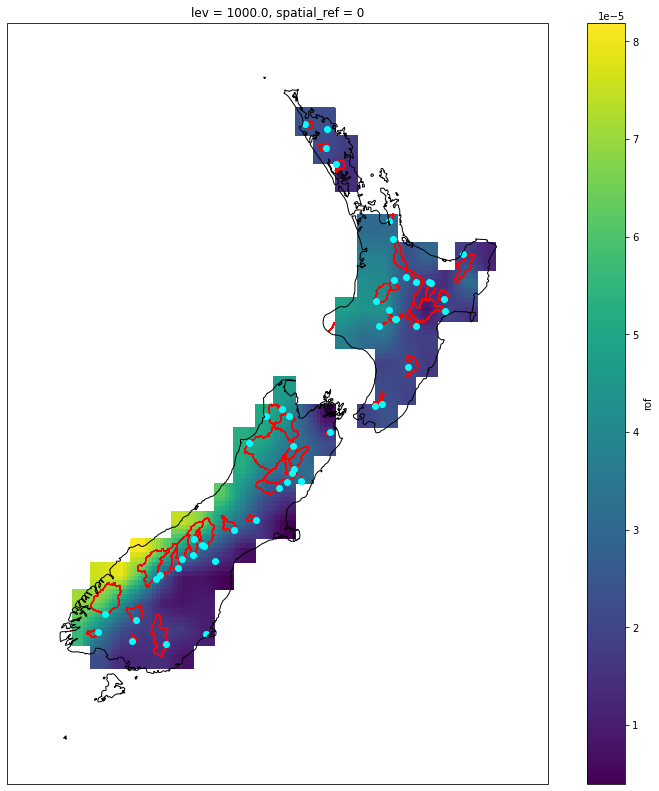

In [14]:
fig,axs = plt.subplots(figsize=(14,14),subplot_kw=dict(projection=ccrs.PlateCarree()))

mem_interp.mean('time').plot(ax=axs)

lats = []
lons = []
for site in obs_df.columns:
    lat,lon = meta_df.loc[int(site)][['gauge_lat','gauge_lon']]
    lats.append(lat)
    lons.append(lon)
    ts = ens_mem_season.interp(lat=lat,lon=lon)
    #print(ts)

catchment_data['geometry'].plot(ax=axs,facecolor="none", edgecolor='red',linewidth=1)

axs.scatter(lons,lats,c='cyan')

axs.coastlines()
axs.add_feature(cf.BORDERS)
axs.set_extent([165,180, -49,-33])#, crs=noproj)


In [ ]:
fig,axs = plt.subplots(1,3,figsize=(18,18),subplot_kw=dict(projection=ccrs.PlateCarree()))


for i,place in enumerate(['catchment','gauge','centroid']):
    
    if i == 0:
        mem_interp.mean('time').plot(ax=axs[0],add_colorbar=False)
        catchment_data['geometry'].plot(ax=axs[0],facecolor="none", edgecolor='red',linewidth=1)

    else:
        lats = []
        lons = []
        for site in obs_df.columns:
            lat,lon = meta_df.loc[int(site)][[f'{place}_lat',f'{place}_lon']]
            lats.append(lat)
            lons.append(lon)
            ts = ens_mem_season.interp(lat=lat,lon=lon)

        ens_mem_season.mean('time').plot(ax=axs[i],add_colorbar=False)

        catchment_data['geometry'].plot(ax=axs[i],facecolor="none", edgecolor='red',linewidth=1)
        axs[i].scatter(lons,lats,c='cyan',s=8)

    axs[i].coastlines()
    axs[i].add_feature(cf.BORDERS)
    axs[i].set_extent([165,180, -49,-33])#, crs=noproj)
    
    axs[i].set_title(place)



In [20]:

def write_dataframe(procesing,direc,var,scen,number,s):
    ens_mem_season = xr.open_dataarray(f'{direc}{var}/full/{var}_Amon_d4PDF_{scen}_m{number}_{processing}_{s}_1951-2021.nc')
         
    ens_mem_season = ens_mem_season.rio.write_crs("EPSG:4326")
    ens_mem_season = ens_mem_season.isel(lev=0)
    ens_mem_season = ens_mem_season.transpose('time','lat','lon')
    ens_mem_season = ens_mem_season.rio.set_spatial_dims('lon','lat')

    mem_interp = ens_mem_season.rio.reproject(ens_mem_season.rio.crs,shape=(150,150),resampling=Resampling.bilinear)

    df_dict = {'time':ens_mem_season.time.values}

    for site in seasonal_flow_df.columns:
        try:
            catchment_geo = catchment_data.loc[[float(site)]]
            model_catchment = mem_interp.rio.clip(catchment_geo.geometry,catchment_data.crs,all_touched=True)

            df_dict[site] = model_catchment.mean(['x','y']).values

        except KeyError as e:
            continue
                    
    df = pd.DataFrame(df_dict)
    
        
    df.to_csv(f'{direc}{var}/full/catchment_resolution/{var}_d4PDF_{scen}_m{number}_{processing}_{s}_1951-2021.csv')

    


In [21]:
'''
Write ensemble member csv files with catchment-based ROF time series
'''

processing = 'raw' #gaussian

var = 'ROF'
direc = f'/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/d4PDF/{processing}/'

for scen in ['HPB','HPB_NAT']:

    print(scen)

    for s in ['winter','spring','summer','autumn']:
        print(s)

        for ens_mem in range(1,101):
            print(ens_mem)
            
            if ens_mem == 100:
                number = '100'
            else:
                number = '00' + str(ens_mem) if ens_mem < 10 else '0' + str(ens_mem)
            #print(f'{direc}{var}/{var}_Amon_d4PDF_{scen}_m{number}_{processing}_{s}_1951-2021.nc')
            write_dataframe(processing,direc,var,scen,number,s)
            

HPB
winter
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
spring
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
summer
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
autumn
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34

In [4]:
'''
write mean files
'''
processing = 'raw'
var = 'ROF'
direc = f'/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/d4PDF/{processing}/'

for scen in ['HPB','HPB_NAT']:

    for s in ['winter','spring','summer','autumn']:

        dfs = []
        for ens_mem in range(1,101):
            
            if ens_mem == 100:
                number = '100'
            else:
                number = '00' + str(ens_mem) if ens_mem < 10 else '0' + str(ens_mem)

            df = pd.read_csv(f'{direc}{var}/full/catchment_resolution/{var}_d4PDF_{scen}_m{number}_{processing}_{s}_1951-2021.csv')

            df = df.set_index('time').drop('Unnamed: 0',axis=1)
            
            dfs.append(df)
        
            
        ens_mean_df = sum(dfs)/len(dfs)
        ens_mean_df.to_csv(f'{direc}{var}/full/catchment_resolution/{var}_d4PDF_{scen}_ensMean_{processing}_{s}_1951-2021.csv')